In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import wfdb
from tqdm import tqdm

# HELPER FUNCTIONS

In [8]:
def load_metadata(data_path: str, sampling_rate: int = 100) -> pd.DataFrame:
    df = pd.read_csv(os.path.join(data_path, "ptbxl_database.csv"), index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(ast.literal_eval)
 
    # Load SCP code descriptions
    agg = pd.read_csv(os.path.join(data_path, "scp_statements.csv"), index_col=0)
    agg = agg[agg.rhythm == 1]  # keep rhythm-level annotations
 
    # Binary label: 1 = has at least one abnormal rhythm code
    def is_normal(scp_dict):
        for code in scp_dict:
            if code == "NORM":
                return 0          # normal
        return 1                  # abnormal
 
    df["label"] = df.scp_codes.apply(is_normal)
    df["filename"] = df[f"filename_lr" if sampling_rate == 100 else "filename_hr"]
    return df
 

In [9]:
def get_label(scp_codes):
    norm_likelihood = scp_codes.get('NORM', 0.0)
    
    has_confident_abnormal = any(
        likelihood > 50
        for code, likelihood in scp_codes.items()
        if code != 'NORM' and likelihood > 50
    )
    
    if norm_likelihood > 50:
        return 0  # Normal
    elif has_confident_abnormal:
        return 1  # Abnormal
    else:
        return -1  # Discard

In [10]:
def load_signal(filename, data_path):
    record = wfdb.rdsamp(data_path + filename)
    return record[0]  # shape: (1000, 12)

In [ ]:
def plot_ecg(signal, lead=0, label=None, fs=100):
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    time = np.arange(signal.shape[0]) / fs

    plt.figure(figsize=(12, 3))
    plt.plot(time, signal[:, lead], linewidth=0.8)
    plt.title(f"Lead {lead_names[lead]} - {'Normal' if label == 0 else 'Abnormal'}" if label is not None else f"Lead {lead_names[lead]}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (mV)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Loading data

In [11]:
DATA_PATH   = "ECG-dataset/"   
SAMPLING    = 100                 # 100 Hz or 500 Hz 
LEAD        = 2                   # Lead index 0–11  (1 = Lead II)

In [12]:
df_metadata = load_metadata(DATA_PATH)
print('before filtering df contains :')
print(len(df_metadata))
# print(df_metadata.head)

before filtering df contains :
21799


## cleaning the ecgs 
NORM > 50 -> final label = normal (0)

NORM ≤ 50 or absent, AND any non-NORM code > 50 -> final label = abnormal (1)

NORM ≤ 50 or absent, AND no non-NORM code > 50 -> discard ECG

In [13]:
df_metadata['label'] = df_metadata['scp_codes'].apply(get_label)
df_meta_clean = df_metadata[df_metadata['label'] != -1]
print('after filtering df contains :')
print(len(df_meta_clean))

after filtering df contains :
19683


In [18]:
normal = df_meta_clean[df_meta_clean['label'] == 0]
abnormal = df_meta_clean[df_meta_clean['label'] == 1]
print(f"Normal: {(df_meta_clean['label'] == 0).sum()}, Abnormal: {(df_meta_clean['label'] == 1).sum()}")

signals = []
for filename in tqdm(df_meta_clean['filename_lr'], desc='Loading signals'):
    signal = load_signal(filename, DATA_PATH)
    signals.append(signal)

df_meta_clean['signal'] = signals
print(f"Signal shape: {df_meta_clean['signal'].iloc[0].shape}")

Normal: 8933, Abnormal: 10750


Loading signals: 100%|██████████| 19683/19683 [03:30<00:00, 93.30it/s] 

Signal shape: (1000, 12)



/tmp/ipykernel_311/3654199268.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meta_clean['signal'] = signals


In [19]:
train_subset = df_meta_clean[df_meta_clean['strat_fold'] <= 7]
val_subset   = df_meta_clean[df_meta_clean['strat_fold'].isin([8, 9])]
test_subset  = df_meta_clean[df_meta_clean['strat_fold'] == 10]
print(f"Train size: {len(train_subset)}, Val size: {len(val_subset)}, Test size: {len(test_subset)}")

Train size: 13783, Val size: 3936, Test size: 1964


In [20]:
X_train = np.stack(train_subset['signal'].values)
X_val   = np.stack(val_subset['signal'].values)

y_train = train_subset['label'].values.astype(np.float32)
y_val   = val_subset['label'].values.astype(np.float32)

# normalize per lead using train stats only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train labels — Normal: {(y_train==0).sum()}, Abnormal: {(y_train==1).sum()}")
print(f"Val labels   — Normal: {(y_val==0).sum()}, Abnormal: {(y_val==1).sum()}")


Train: (13783, 1000, 12), Val: (3936, 1000, 12)
Train labels — Normal: 6275, Abnormal: 7508
Val labels   — Normal: 1760, Abnormal: 2176


In [22]:
from tsai.all import *

# transpose to (batch, channels, timesteps) for tsai
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).permute(0, 2, 1)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

train_ds = TSDatasets(X_train_t, y_train_t)
val_ds   = TSDatasets(X_val_t,   y_val_t)

dls = TSDataLoaders.from_dsets(train_ds, val_ds, bs=16)

In [23]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTM(c_in=12, c_out=2, hidden_size=64, n_layers=2, bidirectional=True)
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=RocAucBinary())



<div></div>

SuggestedLRs(valley=0.0014454397605732083)

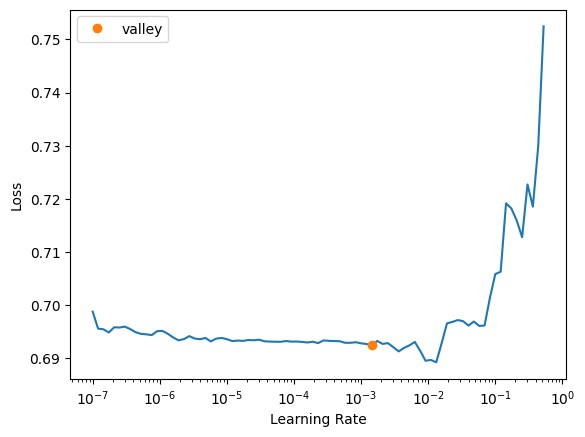

In [24]:
# find a good learning rate
learn.lr_find()

In [26]:
learn.fit_one_cycle(50, lr_max=1e-3)

epoch,train_loss,valid_loss,roc_auc_score,time
0,0.327045,0.342973,0.919930,00:26
1,0.340601,0.352161,0.912448,00:26
2,0.328821,0.340528,0.922374,00:24
3,0.319152,0.347122,0.926012,00:26
4,0.391759,0.442462,0.881502,00:26
5,0.398038,0.419363,0.878840,00:22
6,0.490829,0.454820,0.863293,00:15
7,0.417409,0.413174,0.904861,00:13
8,0.400091,0.411046,0.895278,00:15
9,0.364308,0.372408,0.924611,00:16


In [29]:
signals = []
for filename in tqdm(test_subset['filename_lr'], desc='Loading test signals'):
    signals.append(load_signal(filename, DATA_PATH))

X_test = np.stack(signals)
y_test = test_subset['label'].values.astype(np.float32)

# normalize using train stats
X_test = (X_test - mean) / (std + 1e-8)

# transpose for tsai
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# get predictions
test_ds     = TSDatasets(X_test_t, y_test_t)
test_loader = TSDataLoaders.from_dsets(test_ds, bs=16, shuffle=False)

Loading test signals: 100%|██████████| 1964/1964 [00:11<00:00, 172.28it/s]


In [30]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

probs, targets = learn.get_preds(dl=test_loader.train)

# probs shape: (n, 2) — take class 1 probability
probs_positive = probs[:, 1].numpy()
preds = (probs_positive > 0.5).astype(int)

# metrics
auroc = roc_auc_score(y_test, probs_positive)
print(f"Test AUROC: {auroc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, preds, target_names=['Normal', 'Abnormal'])}")

Test AUROC: 0.9305

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.89      0.86       898
    Abnormal       0.90      0.86      0.88      1066

    accuracy                           0.87      1964
   macro avg       0.87      0.87      0.87      1964
weighted avg       0.87      0.87      0.87      1964

